# 2 · Forward kinematics

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Rudip1/learn-manipulator-control/blob/main/2_notebooks/exercises/02_forward_kinematics.ipynb)

Theory: [`1_theory/02_forward_kinematics.md`](../../1_theory/02_forward_kinematics.md) · notation:
[`00_notation.md`](../../1_theory/00_notation.md)

In [1]:
# Install the module when it is not importable yet (Colab, fresh environment).
import importlib.util
if importlib.util.find_spec("manipulator_control") is None:
    %pip install -q git+https://github.com/Rudip1/learn-manipulator-control
if importlib.util.find_spec("pinocchio") is None:
    %pip install -q pin

In [2]:
import numpy as np
import matplotlib.pyplot as plt

import manipulator_control as mc
from manipulator_control import plotting
from manipulator_control.pinocchio_ref import frame_poses, model_from_chain

plt.rcParams.update({"figure.dpi": 80, "axes.grid": True})
np.set_printoptions(precision=4, suppress=True)
rng = np.random.default_rng(2)

## Recap

- Standard DH: frame $\{i\}$ on link $i$, $z_{i-1}$ along joint $i$; four parameters per link and
  ${}^{i-1}T_i = R_z(\theta_i)T_z(d_i)T_x(a_i)R_x(\alpha_i)$ (eq. 2.1). The joint variable enters $\theta_i$
  (revolute) or $d_i$ (prismatic).
- Forward kinematics chains the link transforms: $T_e = T_0\,{}^{0}T_1\cdots{}^{n-1}T_n\,{}^{n}T_e$ (eq. 2.2).
- Product of exponentials: $T_e(q) = e^{[\mathcal S_1]q_1}\cdots e^{[\mathcal S_n]q_n}M$ with screw axes and $M$
  read at the home configuration $q = 0$ (eq. 2.4); body form $M e^{[\mathcal B_1]q_1}\cdots$ (eq. 2.5).
- Same arm both ways: $\mathcal S_i$ is the $z$ axis of DH frame $i-1$ at $q = 0$ (eq. 2.7).

## A planar three-link arm

A `SerialChain` is a list of `DHLink`s. `frames(q)` returns $T_0, T_1, \dots, T_n, T_e$.

[DHLink(a=0.75, alpha=0, d=0, theta=0, type=Revolute), DHLink(a=0.5, alpha=0, d=0, theta=0, type=Revolute), DHLink(a=0.5, alpha=0, d=0, theta=0, type=Revolute)]


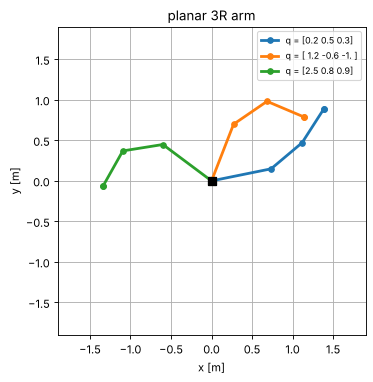

FK: [-0.058  -1.2874  0.    ]  closed form: [-0.058  -1.2874  0.    ]


In [3]:
lengths = [0.75, 0.5, 0.5]
arm = mc.SerialChain([mc.DHLink(a=l) for l in lengths])  # same as mc.robots.planar(lengths)
print(arm.links)

fig, ax = plt.subplots(figsize=(5, 5))
for k, q in enumerate([np.array([0.2, 0.5, 0.3]), np.array([1.2, -0.6, -1.0]), np.array([2.5, 0.8, 0.9])]):
    plotting.draw_planar_arm(ax, arm.frames(q), color=f"C{k}", label=f"q = {q}")
plotting.planar_axes(ax, limit=1.9, title="planar 3R arm")
ax.legend(fontsize=8)
plt.show()

# Check against the closed form (eq. 2.3 extended to three links).
q = rng.uniform(-np.pi, np.pi, 3)
angles = np.cumsum(q)
p_closed = np.array([np.dot(lengths, np.cos(angles)), np.dot(lengths, np.sin(angles)), 0.0])
print("FK:", arm.end_effector(q)[:3, 3], " closed form:", p_closed)

## Workspace of the two-link arm

Sampling joint space and plotting where the end-effector lands shows the reachable set: an annulus with radii
$|l_1 - l_2|$ and $l_1 + l_2$.

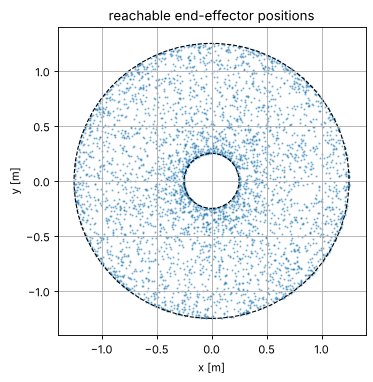

radius range of the samples: [0.250, 1.250]


In [4]:
two = mc.robots.planar([0.75, 0.5])
Q = rng.uniform(-np.pi, np.pi, (4000, 2))
P = np.array([two.end_effector(q)[:2, 3] for q in Q])
fig, ax = plt.subplots(figsize=(5, 5))
ax.scatter(P[:, 0], P[:, 1], s=1, alpha=0.4)
for r in (0.25, 1.25):
    ax.add_patch(plt.Circle((0, 0), r, fill=False, color="k", linestyle="--"))
plotting.planar_axes(ax, limit=1.4, title="reachable end-effector positions")
plt.show()
r = np.linalg.norm(P, axis=1)
print(f"radius range of the samples: [{r.min():.3f}, {r.max():.3f}]")

## The PUMA 560

Standard DH table from section 2.2. At the home configuration the hand computation of the theory gives
$p_e = (a_2 + a_3, -d_3, d_4)$ and $R_e = I$.

1 DHLink(a=0, alpha=1.5708, d=0, theta=0, type=Revolute)
2 DHLink(a=0.4318, alpha=0, d=0, theta=0, type=Revolute)
3 DHLink(a=0.0203, alpha=-1.5708, d=0.15005, theta=0, type=Revolute)
4 DHLink(a=0, alpha=1.5708, d=0.4318, theta=0, type=Revolute)
5 DHLink(a=0, alpha=-1.5708, d=0, theta=0, type=Revolute)
6 DHLink(a=0, alpha=0, d=0, theta=0, type=Revolute)
T_e(0) =
 [[ 1.      0.      0.      0.4521]
 [ 0.      1.      0.     -0.15  ]
 [ 0.      0.      1.      0.4318]
 [ 0.      0.      0.      1.    ]]


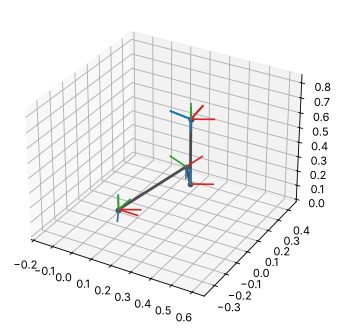

In [5]:
puma = mc.robots.puma560()
for i, link in enumerate(puma.links, start=1):
    print(i, link)
print("T_e(0) =\n", puma.end_effector(np.zeros(6)))

q_show = np.array([0.5, np.pi / 4, -np.pi / 4, 0.0, np.pi / 3, 0.0])
fig = plt.figure(figsize=(5, 5))
ax = fig.add_subplot(projection="3d")
plotting.draw_arm_3d(ax, puma.frames(q_show), frame_length=0.1)
plotting.set_axes_equal(ax)
plt.show()

## The same arm both ways

`to_poe` reads each joint's screw axis from the DH frames at $q = 0$ (eq. 2.7). DH, space POE, body POE and
Pinocchio should agree for every configuration.

In [6]:
poe = mc.to_poe(puma)
print("M =\n", poe.M)
print("screw axes S_i (v, w):\n", np.array(poe.screws))

model, data, ids = model_from_chain(puma)
worst = {"POE space": 0.0, "POE body": 0.0, "Pinocchio": 0.0}
for _ in range(500):
    q = rng.uniform(-np.pi, np.pi, 6)
    T = puma.end_effector(q)
    worst["POE space"] = max(worst["POE space"], np.abs(mc.poe_space(poe, q) - T).max())
    worst["POE body"] = max(worst["POE body"], np.abs(mc.poe_body(poe, q) - T).max())
    worst["Pinocchio"] = max(worst["Pinocchio"], np.abs(frame_poses(model, data, [ids[-1]], q)[0] - T).max())
for name, err in worst.items():
    print(f"max |DH - {name}| over 500 configurations: {err:.1e}")

M =
 [[ 1.      0.      0.      0.4521]
 [ 0.      1.      0.     -0.15  ]
 [ 0.      0.      1.      0.4318]
 [ 0.      0.      0.      1.    ]]
screw axes S_i (v, w):
 [[-0.     -0.     -0.      0.      0.      1.    ]
 [ 0.     -0.     -0.      0.     -1.      0.    ]
 [ 0.     -0.     -0.4318  0.     -1.      0.    ]
 [-0.15   -0.4521  0.      0.      0.      1.    ]
 [ 0.4318 -0.     -0.4521  0.     -1.      0.    ]
 [-0.15   -0.4521  0.      0.      0.      1.    ]]


max |DH - POE space| over 500 configurations: 6.7e-16
max |DH - POE body| over 500 configurations: 6.7e-16
max |DH - Pinocchio| over 500 configurations: 2.2e-16


## ✏️ Exercises

### ✏️ 1. The DH link transform

Implement eq. (2.1) in NumPy, either as the product of four elementary transforms or as the explicit matrix.

In [7]:
def dh(a, alpha, d, theta):
    ### BEGIN SOLUTION
    ct, st, ca, sa = np.cos(theta), np.sin(theta), np.cos(alpha), np.sin(alpha)
    return np.array([[ct, -st * ca, st * sa, a * ct],
                     [st, ct * ca, -ct * sa, a * st],
                     [0.0, sa, ca, d],
                     [0.0, 0.0, 0.0, 1.0]])
    ### END SOLUTION

In [8]:
for _ in range(20):
    args = rng.uniform(-2, 2, 4)
    assert np.allclose(dh(*args), mc.dh_transform(*args))
print("✓ dh")

✓ dh


### ✏️ 2. A DH table with a prismatic joint

A planar "polar" arm: joint 1 rotates about the world $z$ axis, joint 2 slides radially in the $x$–$y$ plane,
so the end-effector is at $q_2(\cos q_1, \sin q_1, 0)$. Write its DH table. (Hint: $z_1$ must point along the
sliding direction, so link 1 needs a twist $\alpha_1$ and an angle offset $\theta^0_1$.)

In [9]:
### BEGIN SOLUTION
polar = mc.SerialChain([
    mc.DHLink(a=0.0, alpha=np.pi / 2, d=0.0, theta=np.pi / 2, type=mc.JointType.Revolute),
    mc.DHLink(a=0.0, alpha=0.0, d=0.0, theta=0.0, type=mc.JointType.Prismatic),
])
### END SOLUTION

In [10]:
for _ in range(20):
    q1, q2 = rng.uniform(-np.pi, np.pi), rng.uniform(0.1, 1.5)
    assert np.allclose(polar.end_effector([q1, q2])[:3, 3], [q2 * np.cos(q1), q2 * np.sin(q1), 0.0])
print("✓ polar arm")

✓ polar arm


### ✏️ 3. Screw axes by hand

For the planar two-link arm ($l_1 = 0.75$, $l_2 = 0.5$) write the space screw axes $\mathcal S_1$,
$\mathcal S_2$ and the home pose $M$ without calling `to_poe`. Use eq. (1.12): a revolute joint about $\hat\omega$
through $p$ has $\mathcal S = (-\hat\omega\times p, \hat\omega)$.

In [11]:
l1, l2 = 0.75, 0.5
### BEGIN SOLUTION
S1 = np.array([0, 0, 0, 0, 0, 1.0])     # axis z through the origin
S2 = np.array([0, -l1, 0, 0, 0, 1.0])   # axis z through (l1, 0, 0): -z x (l1,0,0) = (0, -l1, 0)
M = mc.translation([l1 + l2, 0, 0])
### END SOLUTION

In [12]:
mine = mc.PoeChain(M, [S1, S2])
for _ in range(20):
    q = rng.uniform(-np.pi, np.pi, 2)
    assert np.allclose(mc.poe_space(mine, q), two.end_effector(q))
print("✓ screw axes")

✓ screw axes


### ✏️ 4. Body screw axes by hand

Now the screws expressed in the end-effector frame at home, $\mathcal B_i = \mathrm{Ad}_{M^{-1}}\mathcal S_i$.
Work them out geometrically: in the home end-effector frame, where do the two joint axes pass?

In [13]:
### BEGIN SOLUTION
# In the end-effector frame at home, joint 1 is at x = -(l1 + l2) and joint 2 at x = -l2, both along z.
B1 = np.array([0, l1 + l2, 0, 0, 0, 1.0])   # -z x (-(l1+l2), 0, 0) = (0, l1 + l2, 0)
B2 = np.array([0, l2, 0, 0, 0, 1.0])
### END SOLUTION

In [14]:
B_ref = mc.body_screws(mc.to_poe(two))
assert np.allclose(B1, B_ref[0]) and np.allclose(B2, B_ref[1])
print("✓ body screws")

✓ body screws


## 🔨 Break it

### 🔨 1. A modified-DH table in the standard formula

In Craig's modified convention the planar arm's table has $a_{i-1}$ in row $i$: the lengths are shifted down
one row, $(0, l_1, l_2)$, and the last length lives in a tool transform. Feed that table into the standard
formula (eq. 2.1) and you get a different arm — the first link vanishes and the last one is missing.

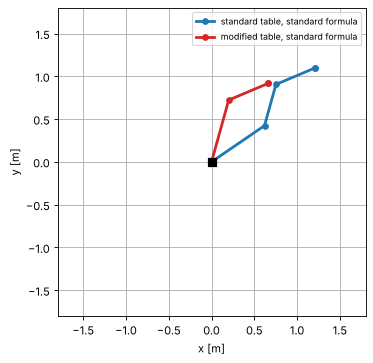

end-effector error: 0.5815360519936118 m


In [15]:
modified_rows = [0.0, 0.75, 0.5]  # a_{i-1} column of the modified-DH table
wrong = mc.SerialChain([mc.DHLink(a=a) for a in modified_rows])
q = np.array([0.6, 0.7, -0.9])
fig, ax = plt.subplots(figsize=(5, 5))
plotting.draw_planar_arm(ax, arm.frames(q), color="C0", label="standard table, standard formula")
plotting.draw_planar_arm(ax, wrong.frames(q), color="C3", label="modified table, standard formula")
plotting.planar_axes(ax, limit=1.8)
ax.legend(fontsize=8)
plt.show()
print("end-effector error:", np.linalg.norm(arm.end_effector(q)[:3, 3] - wrong.end_effector(q)[:3, 3]), "m")

### 🔨 2. The product in the wrong order

Two rotations about parallel axes through different points do not commute. Reversing the order in eq. (2.4)
is right only when one of the joints is at zero.

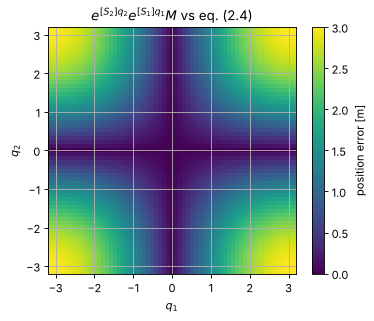

In [16]:
poe2 = mc.to_poe(two)
grid = np.linspace(-np.pi, np.pi, 61)
err = np.zeros((grid.size, grid.size))
for i, q1 in enumerate(grid):
    for j, q2 in enumerate(grid):
        right = mc.poe_space(poe2, [q1, q2])
        reversed_ = mc.exp_se3(poe2.screws[1] * q2) @ mc.exp_se3(poe2.screws[0] * q1) @ poe2.M
        err[j, i] = np.linalg.norm(right[:3, 3] - reversed_[:3, 3])
plt.figure(figsize=(5, 4))
plt.pcolormesh(grid, grid, err, shading="auto")
plt.colorbar(label="position error [m]")
plt.xlabel("$q_1$"); plt.ylabel("$q_2$"); plt.title(r"$e^{[S_2]q_2}e^{[S_1]q_1}M$ vs eq. (2.4)")
plt.show()

### 🔨 3. Screw axes read at the current configuration

Eq. (2.4) needs the axes at the home configuration. Read them (and $M$) from the frames at some other
configuration $q^\ast$ and plug in $q$: the motion $q^\ast$ is counted twice. What you have built is a valid POE
whose home is $q^\ast$ — it is correct only for the joint *displacement* $q - q^\ast$.

In [17]:
def screws_at(chain, q_star):
    frames = chain.frames(q_star)  # T_0 .. T_n, T_e; joint i uses frame i-1 (all arms here are revolute)
    return [np.concatenate([-np.cross(T[:3, 2], T[:3, 3]), T[:3, 2]]) for T in frames[:-2]]

q_star = np.array([0.4, 0.8, -0.3, 0.2, 0.5, 0.1])
bad = mc.PoeChain(puma.end_effector(q_star), screws_at(puma, q_star))
errs_q, errs_dq = [], []
for _ in range(200):
    q = rng.uniform(-np.pi, np.pi, 6)
    errs_q.append(np.linalg.norm(mc.poe_space(bad, q)[:3, 3] - puma.end_effector(q)[:3, 3]))
    errs_dq.append(np.linalg.norm(mc.poe_space(bad, q - q_star)[:3, 3] - puma.end_effector(q)[:3, 3]))
print(f"axes at q*, evaluated at q:      mean position error {np.mean(errs_q):.3f} m")
print(f"axes at q*, evaluated at q - q*: max position error  {np.max(errs_dq):.1e} m")

axes at q*, evaluated at q:      mean position error 0.394 m
axes at q*, evaluated at q - q*: max position error  1.4e-15 m


## What to remember

- A DH table is four numbers per link and a convention; always know which convention (standard or modified).
- Forward kinematics is a product of link transforms; keep every intermediate frame, the Jacobian needs them.
- Product of exponentials: one screw per joint, read in one frame at the home configuration, multiplied left to
  right in joint order and followed by $M$.
- The screw of joint $i$ is the $z$ axis of DH frame $i-1$ at $q = 0$ — that is how the two descriptions meet.